In [1]:
import pandas as pd

df = pd.read_csv("train_u6lujuX_CVtuZ9i (1).csv")

print(df.head())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [3]:
print(df.isnull().sum())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols = ['Gender','Married','Education',
        'Self_Employed','Property_Area',
        'Loan_Status']

for col in cols:
    df[col] = le.fit_transform(df[col])

print(df.head())

    Loan_ID  Gender  Married Dependents  Education  Self_Employed  \
0  LP001002       1        0          0          0              0   
1  LP001003       1        1          1          0              0   
2  LP001005       1        1          0          0              1   
3  LP001006       1        1          0          1              0   
4  LP001008       1        0          0          0              0   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History  Property_Area  Loan_Status  
0             1.0              2            1  
1             1.0              0            0  
2             

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df[['ApplicantIncome','LoanAmount',
        'Credit_History']]

y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [7]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.7479674796747967


In [8]:
print(df.isnull().sum())

Loan_ID               0
Gender                0
Married               0
Dependents           15
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [9]:
df = df.dropna()

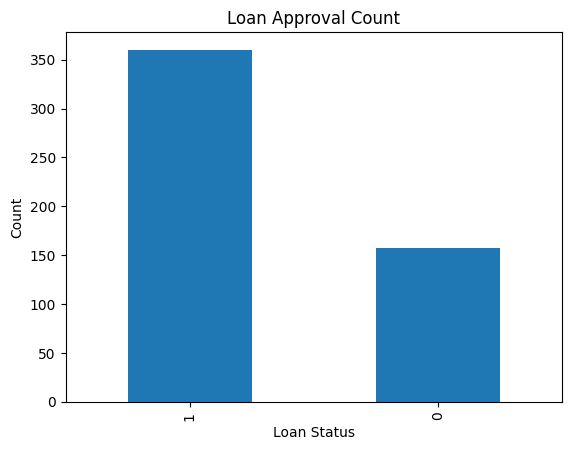

In [10]:
import matplotlib.pyplot as plt

df['Loan_Status'].value_counts().plot(kind='bar')

plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.title("Loan Approval Count")

plt.show()

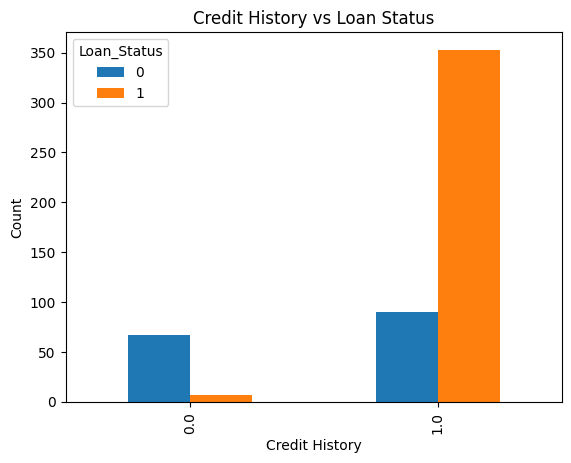

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

pd.crosstab(df['Credit_History'],
            df['Loan_Status']).plot(kind='bar')

plt.title("Credit History vs Loan Status")
plt.xlabel("Credit History")
plt.ylabel("Count")

plt.show()

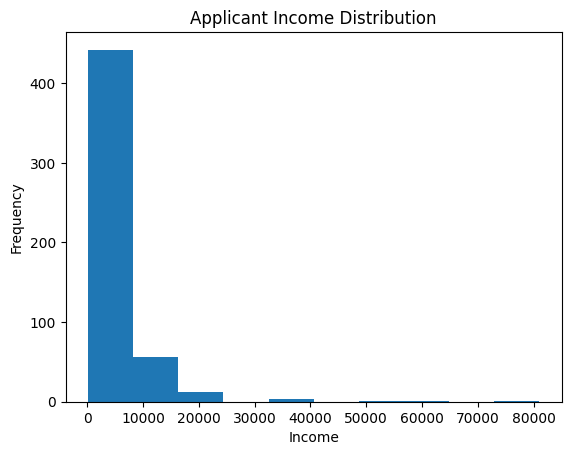

In [12]:
plt.hist(df['ApplicantIncome'])

plt.title("Applicant Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")

plt.show()

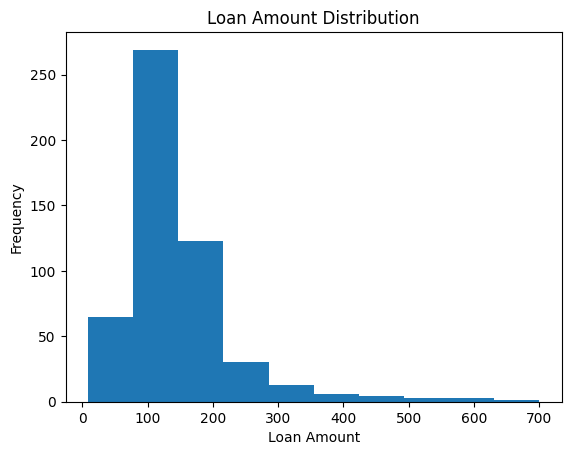

In [13]:
plt.hist(df['LoanAmount'])

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

plt.show()